In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

In [4]:
train_data = './chest_xray/train'
test_data  = './chest_xray/test'

In [5]:
def create_dataframe(data_path):
    filepaths, labels = [], []
    for folder in os.listdir(data_path):
        folder_path = os.path.join(data_path, folder)
        if not os.path.isdir(folder_path):
            continue
        for file in os.listdir(folder_path):
            if file.startswith('.'):
                continue
            filepaths.append(os.path.join(folder_path, file))
            labels.append(folder)
    return pd.DataFrame({'filepaths': filepaths, 'label': labels})

train_df = create_dataframe(train_data)
test_df  = create_dataframe(test_data)

# Split training data into 80/20 train-validation
train_df, valid_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df['label'], random_state=42
)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 4172
Validation samples: 1044
Test samples: 624


In [6]:
img_size = (224, 224)
batch_size = 16

train_gen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_gen = ImageDataGenerator(rescale=1/255)
test_gen  = ImageDataGenerator(rescale=1/255)

train_flow = train_gen.flow_from_dataframe(
    train_df, x_col='filepaths', y_col='label',
    target_size=img_size, class_mode='categorical',
    color_mode='rgb', shuffle=True, batch_size=batch_size
)

valid_flow = valid_gen.flow_from_dataframe(
    valid_df, x_col='filepaths', y_col='label',
    target_size=img_size, class_mode='categorical',
    color_mode='rgb', shuffle=False, batch_size=batch_size
)

test_flow = test_gen.flow_from_dataframe(
    test_df, x_col='filepaths', y_col='label',
    target_size=img_size, class_mode='categorical',
    color_mode='rgb', shuffle=False, batch_size=batch_size
)

Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


In [7]:
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3))

# Freeze convolutional base initially
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(train_flow.class_indices), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 [==============================] - 26s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                        

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
checkpoint = ModelCheckpoint("best_vgg16_model.h5", save_best_only=True, monitor='val_accuracy', mode='max')

In [9]:
print("\n=== Stage 1: Training Fully Connected Layers ===\n")

history = model.fit(
    train_flow,
    validation_data=valid_flow,
    epochs=12,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=2
)


=== Stage 1: Training Fully Connected Layers ===

Epoch 1/12
261/261 - 99s - loss: 0.4247 - accuracy: 0.8030 - val_loss: 0.3925 - val_accuracy: 0.9109 - lr: 1.0000e-04 - 99s/epoch - 380ms/step
Epoch 2/12
261/261 - 75s - loss: 0.2769 - accuracy: 0.8828 - val_loss: 0.2325 - val_accuracy: 0.9090 - lr: 1.0000e-04 - 75s/epoch - 287ms/step
Epoch 3/12
261/261 - 68s - loss: 0.2508 - accuracy: 0.8921 - val_loss: 0.2146 - val_accuracy: 0.9013 - lr: 1.0000e-04 - 68s/epoch - 260ms/step
Epoch 4/12
261/261 - 63s - loss: 0.2268 - accuracy: 0.9118 - val_loss: 0.2027 - val_accuracy: 0.9071 - lr: 1.0000e-04 - 63s/epoch - 240ms/step
Epoch 5/12
261/261 - 63s - loss: 0.2073 - accuracy: 0.9096 - val_loss: 0.1738 - val_accuracy: 0.9205 - lr: 1.0000e-04 - 63s/epoch - 240ms/step
Epoch 6/12
261/261 - 62s - loss: 0.1954 - accuracy: 0.9173 - val_loss: 0.1992 - val_accuracy: 0.9109 - lr: 1.0000e-04 - 62s/epoch - 239ms/step
Epoch 7/12
261/261 - 67s - loss: 0.1868 - accuracy: 0.9245 - val_loss: 0.1819 - val_accurac

In [10]:
print("\n=== Stage 2: Fine-Tuning Top VGG16 Layers ===\n")

# Unfreeze top 10 layers for fine-tuning
for layer in model.layers[0].layers[-10:]:
    layer.trainable = True

# Recompile with smaller learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training (up to 10 epochs)
fine_tune_history = model.fit(
    train_flow,
    validation_data=valid_flow,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=2
)


=== Stage 2: Fine-Tuning Top VGG16 Layers ===

Epoch 1/10
261/261 - 118s - loss: 0.1828 - accuracy: 0.9288 - val_loss: 0.1518 - val_accuracy: 0.9349 - lr: 1.0000e-05 - 118s/epoch - 452ms/step
Epoch 2/10
261/261 - 69s - loss: 0.1413 - accuracy: 0.9485 - val_loss: 0.1074 - val_accuracy: 0.9579 - lr: 1.0000e-05 - 69s/epoch - 265ms/step
Epoch 3/10
261/261 - 65s - loss: 0.1155 - accuracy: 0.9590 - val_loss: 0.1993 - val_accuracy: 0.9195 - lr: 1.0000e-05 - 65s/epoch - 250ms/step
Epoch 4/10
261/261 - 65s - loss: 0.1190 - accuracy: 0.9561 - val_loss: 0.2173 - val_accuracy: 0.9138 - lr: 1.0000e-05 - 65s/epoch - 248ms/step
Epoch 5/10
261/261 - 69s - loss: 0.0908 - accuracy: 0.9686 - val_loss: 0.2478 - val_accuracy: 0.9080 - lr: 2.0000e-06 - 69s/epoch - 263ms/step


In [11]:
model.load_weights("best_vgg16_model.h5")  # Load best weights
train_loss, train_acc = model.evaluate(train_flow, verbose=0)
val_loss, val_acc = model.evaluate(valid_flow, verbose=0)
test_loss, test_acc = model.evaluate(test_flow, verbose=0)

print("\n=== Final Model Performance ===")
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")


=== Final Model Performance ===
Train Accuracy: 96.19%
Validation Accuracy: 95.79%
Test Accuracy: 89.74%


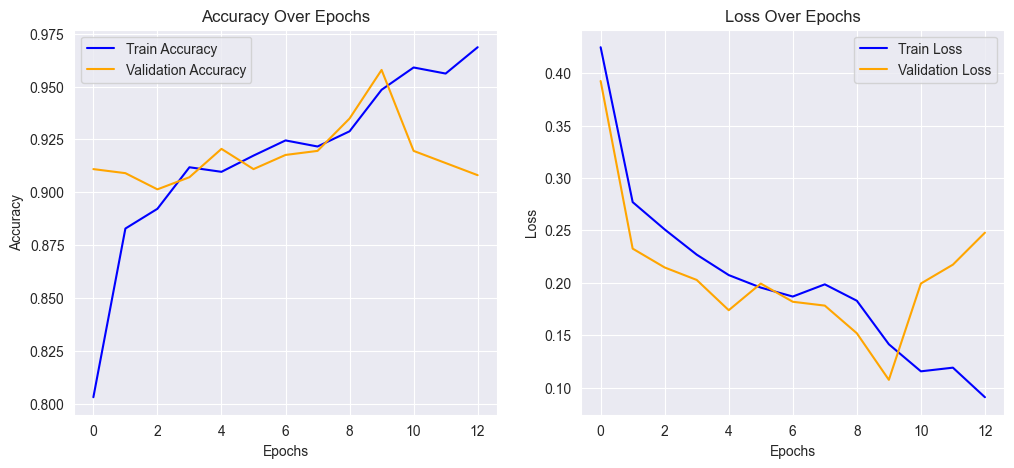

In [12]:
plt.figure(figsize=(12,5))

total_acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
total_val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
total_loss = history.history['loss'] + fine_tune_history.history['loss']
total_val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.subplot(1,2,1)
plt.plot(total_acc, label='Train Accuracy', color='blue')
plt.plot(total_val_acc, label='Validation Accuracy', color='orange')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(total_loss, label='Train Loss', color='blue')
plt.plot(total_val_loss, label='Validation Loss', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

39/39 [==============================] - 6s 139ms/step


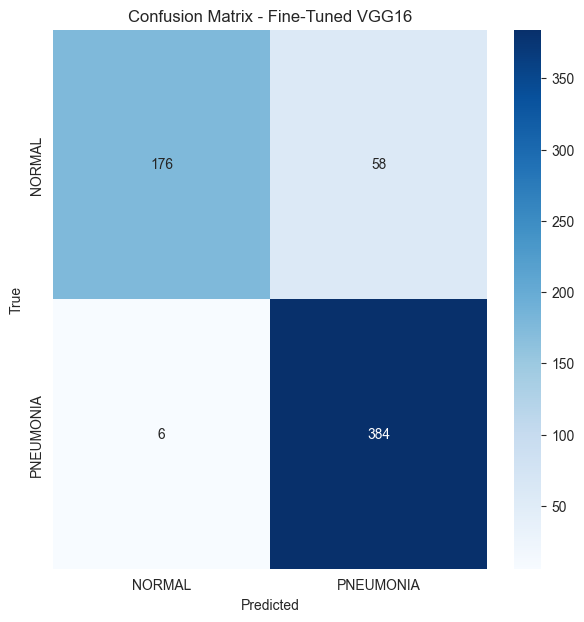


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.75      0.85       234
   PNEUMONIA       0.87      0.98      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.88       624
weighted avg       0.91      0.90      0.89       624



In [13]:
preds = model.predict(test_flow)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(test_flow.classes, y_pred)
classes = list(test_flow.class_indices.keys())

plt.figure(figsize=(7,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fine-Tuned VGG16')
plt.show()

print("\nClassification Report:")
print(classification_report(test_flow.classes, y_pred, target_names=classes))